# Principal components — how many, and why

**Replication Phase 3 · exploratory analysis**

This notebook answers one question: **how many principal components should enter the model as
covariates?**

The pipeline used 5 for the combined cohort, 9 for EUR and 10 for AFR. The analysis plan anticipated
*"most likely 4 or 5"*. The 2026-07-01 meeting decided *"no more than 5–6"*. The three numbers
disagree, and none was justified against the data.

Here the data decides. A plain-language companion, in Portuguese, is at
[`docs/07_pcs_explicados.pt.md`](../../docs/07_pcs_explicados.pt.md).

In [1]:
import sys; sys.path.insert(0, "scripts")
import pc_analysis as pc
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "600",
    "axes.titlecolor": pc.INK, "axes.labelcolor": pc.INK2, "figure.dpi": 110,
})
eig = pc.eigenvalues()
eig.head()

,cohort,PC,eigenvalue,variance_pct,drop_pct
0,combined,1,762.379,33.006135,NaN
1,combined,2,326.940,14.154411,57.115818
2,combined,3,204.934,8.872331,37.317551
3,combined,4,106.893,4.627783,47.840280
4,combined,5,81.414,3.524705,23.835986


## 1. The scree plot

Every PC carries an **eigenvalue** — how much genetic variation it captures. The first captures the
most, the second less, and so on down.

The scree plot shows that decline. Where the curve **stops falling** is the elbow: from there on each
component explains about as much as its neighbour, which is the signature of **noise** rather than
population structure.

One series per panel, so no legend — the title names the cohort.

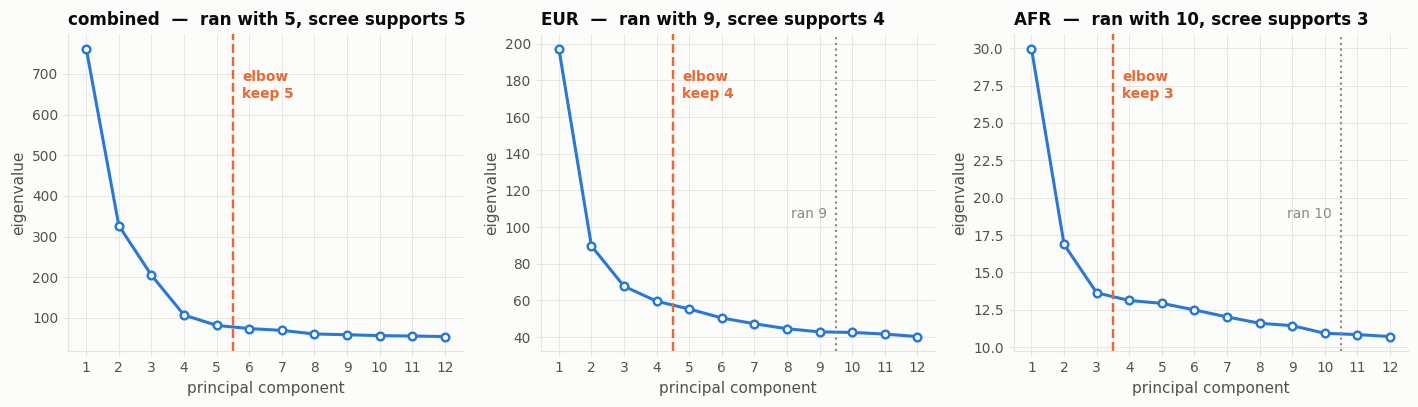

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, coh in zip(axes, ["combined", "EUR", "AFR"]):
    d = eig[eig.cohort == coh].sort_values("PC").head(12)
    k, ran = pc.elbow(eig, coh), pc.WHAT_RAN[coh]
    pc.style(ax)
    ax.plot(d.PC, d.eigenvalue, color=pc.SERIES[0], linewidth=2,
            marker="o", markersize=5, markerfacecolor="#fcfcfb", markeredgewidth=1.6)
    ax.axvline(k + 0.5, color=pc.SERIES[1], linewidth=1.6, linestyle="--")
    # labels in axes fraction, not data coordinates -- in data coordinates the label
    # falls outside the plotted range when the minimum eigenvalue is high (AFR)
    ax.annotate(f"elbow\nkeep {k}", xy=(k + 0.5, 0.80), xycoords=("data", "axes fraction"),
                color=pc.SERIES[1], fontsize=9, ha="left", xytext=(6, 0),
                textcoords="offset points", fontweight="600")
    if ran != k:
        ax.axvline(ran + 0.5, color=pc.MUTED, linewidth=1.4, linestyle=":")
        ax.annotate(f"ran {ran}", xy=(ran + 0.5, 0.42), xycoords=("data", "axes fraction"),
                    color=pc.MUTED, fontsize=9, ha="right", xytext=(-6, 0),
                    textcoords="offset points")
    ax.set_title(f"{coh}  —  ran with {ran}, scree supports {k}", loc="left")
    ax.set_xlabel("principal component"); ax.set_ylabel("eigenvalue")
    ax.set_xticks(range(1, 13))
fig.tight_layout(); plt.show()

## 2. The drop between consecutive PCs

A scree plot depends on its scale, so two people can look at the same one and disagree. The
proportional drop does not: it measures what each PC adds **relative to the one before it**.

The rule used here: the elbow is the first PC whose drop falls **below 10%**. Keep up to the one
before it.

In [3]:
rows = []
for coh in ["combined", "EUR", "AFR"]:
    d = eig[eig.cohort == coh].sort_values("PC").head(8)
    for _, r in d.iterrows():
        rows.append({"cohort": coh, "PC": int(r.PC),
                     "eigenvalue": round(r.eigenvalue, 1),
                     "variance %": round(r.variance_pct, 2),
                     "drop vs previous %": None if pd.isna(r.drop_pct) else round(r.drop_pct, 1),
                     "plateau": "" if pd.isna(r.drop_pct) else ("yes" if r.drop_pct < 10 else "")})
table = pd.DataFrame(rows)
display(table.pivot_table(index="PC", columns="cohort",
                          values="drop vs previous %").round(1))
print("elbow by cohort:",
      {c: pc.elbow(eig, c) for c in ["combined", "EUR", "AFR"]})

cohort,AFR,EUR,combined
PC,,,
2,43.7,54.6,57.1
3,19.2,24.5,37.3
4,3.8,12.0,47.8
5,1.4,7.1,23.8
6,3.4,8.8,9.5
7,3.8,6.3,6.1
8,3.5,5.7,12.7


elbow by cohort: {'combined': 5, 'EUR': 4, 'AFR': 3}


## 3. Cumulative variance

How much of the total variation the first *k* components explain together. Useful as a sanity check,
but **not** as a criterion: in an exome the total variance includes a great deal of technical noise,
so chasing a high percentage pulls in too many components.

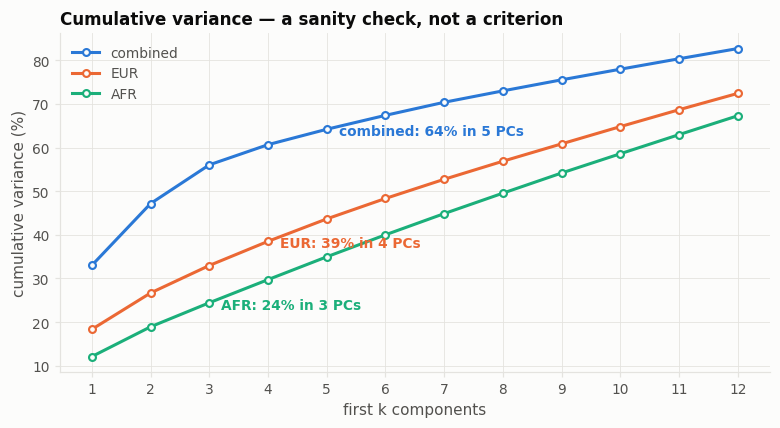

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 4))
pc.style(ax)
for i, coh in enumerate(["combined", "EUR", "AFR"]):
    d = eig[eig.cohort == coh].sort_values("PC").head(12)
    ax.plot(d.PC, d.variance_pct.cumsum(), color=pc.SERIES[i], linewidth=2,
            marker="o", markersize=4.5, markerfacecolor="#fcfcfb",
            markeredgewidth=1.4, label=coh)
    k = pc.elbow(eig, coh)
    y = d[d.PC <= k].variance_pct.sum()
    ax.annotate(f"{coh}: {y:.0f}% in {k} PCs", (k, y), color=pc.SERIES[i],
                fontsize=9, fontweight="600", xytext=(8, -4), textcoords="offset points")
ax.set_xlabel("first k components"); ax.set_ylabel("cumulative variance (%)")
ax.set_title("Cumulative variance — a sanity check, not a criterion", loc="left")
ax.set_xticks(range(1, 13)); ax.legend(frameon=False, labelcolor=pc.INK2, fontsize=9)
fig.tight_layout(); plt.show()

## 4. The plot genetics actually uses: PC1 against PC2

This is where the components stop being abstract. Each point is a person; the axes are the first two
components. Genetically similar people land near each other.

What it shows is that **the components recover ancestry without ever being told about it** — the PCA
saw genotypes only. The clusters emerge on their own.

> **A note on colour.** A scatter is an *all-pairs* form: any group can sit beside any other, and only
> three colours from the palette clear the colour-vision thresholds under those conditions. So the
> overview uses three series (EUR, AFR, other) and the smaller groups get their own panels in
> section 5.

70,925 people
Class
EUR        51867
AFR        14927
EAS         1333
SAS         1080
AMR         1039
UNKNOWN      679


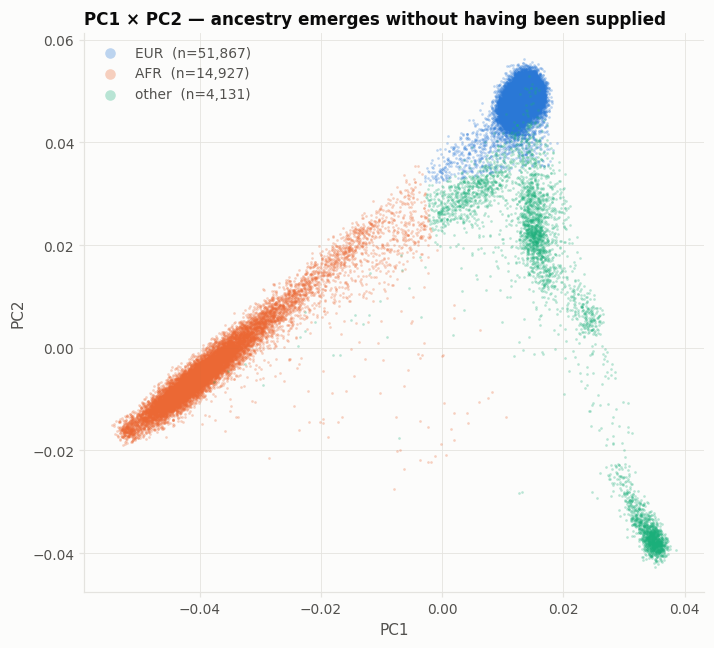

In [5]:
d = pc.pcs_with_ancestry()
print(f"{len(d):,} people")
print(d.Class.value_counts().to_string())

big = ["EUR", "AFR"]
d["group"] = d.Class.where(d.Class.isin(big), "other")

fig, ax = plt.subplots(figsize=(6.6, 6))
pc.style(ax)
for i, g in enumerate(["EUR", "AFR", "other"]):
    s = d[d.group == g]
    ax.scatter(s.PC1, s.PC2, s=3, alpha=0.30, linewidths=0,
               color=pc.SERIES[i], label=f"{g}  (n={len(s):,})", rasterized=True)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("PC1 × PC2 — ancestry emerges without having been supplied", loc="left")
ax.legend(frameon=False, labelcolor=pc.INK2, fontsize=9, markerscale=4)
fig.tight_layout(); plt.show()

## 5. One panel per ancestry

With every group on a single plot the smaller ones disappear beneath the larger, and six colours
would not survive the colour-vision test in a scatter.

The fix is a panel per group: the group of interest coloured, **everything else in grey as context**.
One hue per panel, no contrast problem, and it becomes visible where each group sits.

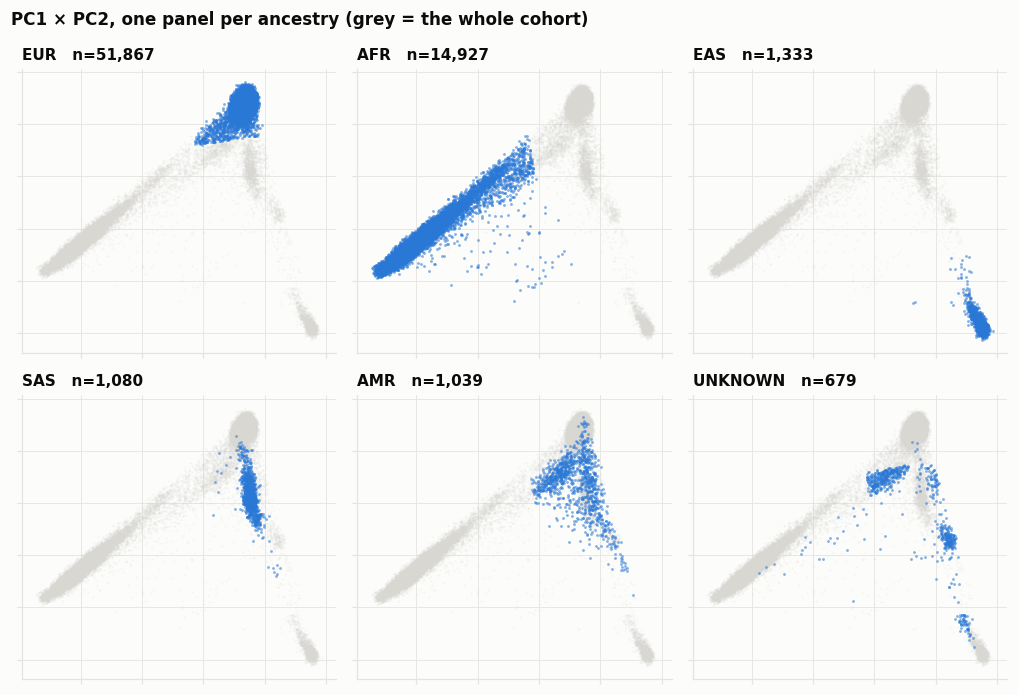

In [6]:
order = d.Class.value_counts().index.tolist()
n = len(order)
fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(3.1 * ((n + 1) // 2), 6.4))
for ax, g in zip(axes.ravel(), order):
    pc.style(ax)
    ax.scatter(d.PC1, d.PC2, s=2, alpha=0.18, linewidths=0,
               color=pc.CONTEXT, rasterized=True)
    s = d[d.Class == g]
    ax.scatter(s.PC1, s.PC2, s=3.5, alpha=0.55, linewidths=0,
               color=pc.SERIES[0], rasterized=True)
    ax.set_title(f"{g}   n={len(s):,}", loc="left", fontsize=10)
    ax.set_xticklabels([]); ax.set_yticklabels([])
for ax in axes.ravel()[n:]:
    ax.axis("off")
fig.suptitle("PC1 × PC2, one panel per ancestry (grey = the whole cohort)",
             x=0.01, ha="left", fontsize=11, fontweight="600", color=pc.INK)
fig.tight_layout(); plt.show()

## 6. Do PC3 and PC4 still carry structure?

If they do, keeping them is justified. If the panels already look like a single cloud, the component
is capturing noise — and that is the argument for truncating.

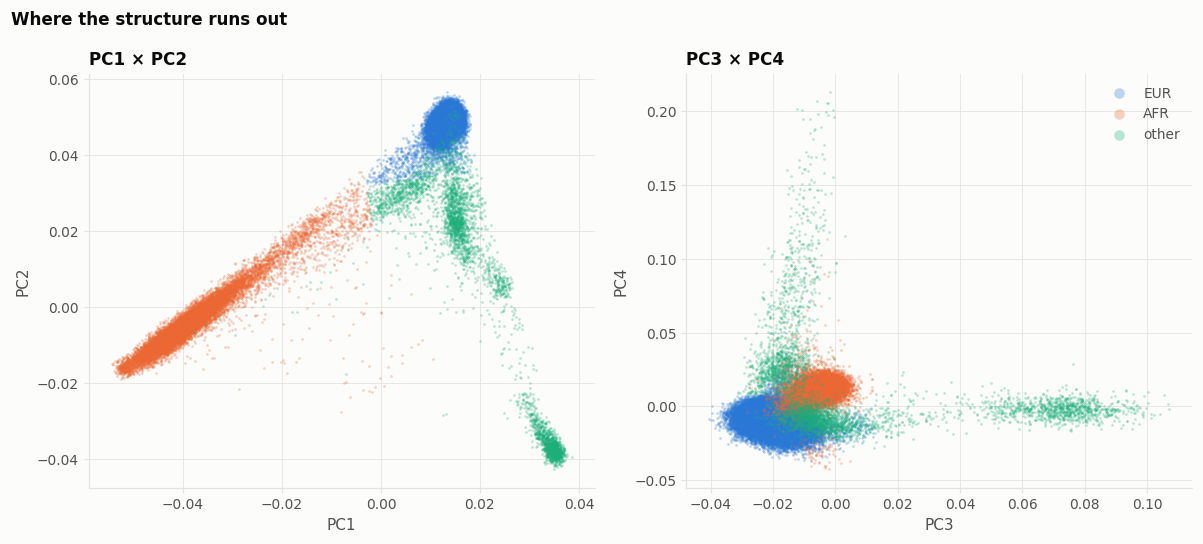

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (a, b) in zip(axes, [("PC1", "PC2"), ("PC3", "PC4")]):
    pc.style(ax)
    for i, g in enumerate(["EUR", "AFR", "other"]):
        s = d[d.group == g]
        ax.scatter(s[a], s[b], s=3, alpha=0.30, linewidths=0,
                   color=pc.SERIES[i], label=g if a == "PC3" else None, rasterized=True)
    ax.set_xlabel(a); ax.set_ylabel(b)
    ax.set_title(f"{a} × {b}", loc="left")
axes[1].legend(frameon=False, labelcolor=pc.INK2, fontsize=9, markerscale=4)
fig.suptitle("Where the structure runs out", x=0.01, ha="left", fontsize=11,
             fontweight="600", color=pc.INK)
fig.tight_layout(); plt.show()

## Conclusion

| cohort | ran with | scree supports | source of the PCs |
|---|---|---|---|
| combined | 5 | **5** ✓ | the release's own PCA |
| EUR | 9 | **4** | a within-ancestry PCA run by the pipeline |
| AFR | 10 | **3** | a within-ancestry PCA run by the pipeline |

**The combined cohort was right.** EUR and AFR used more than double what their own scree supports.

Adopted for the corrected arm: **5 / 4 / 3**. The reproduction arm keeps 5 / 9 / 10, because that is
what ran.

One thing this notebook makes visible: the combined PCs come from the release, while EUR and AFR are
PCAs run **within** each ancestry group — which is the correct practice, since within EUR the relevant
structure is fine-grained and a global PCA cannot see it. It is also why no `variance_explained` file
exists for the combined cohort.

The scree files for EUR and AFR are dated 14 July and the analysis plan named the method: *"I will use
a variance explained plot to determine how many PCs should be used as covariates → this number will
most likely be 4 or 5."* The method was planned and the data was generated. The numbers used do not
come from it.